# Visualize ROI Mask Application in Training Pipeline

This notebook shows how images look before and after applying ROI masks in the training pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.constants import *
from src.helpers import *
from src.OUTDATED_trainable_pipeline import *

%matplotlib inline

Using device: cuda


## Load Data and Setup

In [2]:
# Load data
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print(f"Loaded {len(samples)} samples")

# Get backbone and preprocessing
backbone_name = "vit_b_16"
backbone, preprocess, feature_dim = get_backbone_and_preprocess(backbone_name, DEVICE)

# Select first batch
batch_size = 4
batch_df = samples.iloc[:batch_size]

print("\nBatch samples:")
display(batch_df[["exp_id", "volume", "top_path", "side_path"]])

Loaded 420 samples

Batch samples:


,exp_id,volume,top_path,side_path
0,1,1.06,photos\top_view_images\P2260331.JPG,photos\side_view_images\P2260685.JPG
1,1,2.12,photos\top_view_images\P2260332.JPG,photos\side_view_images\P2260686.JPG
2,1,3.18,photos\top_view_images\P2260333.JPG,photos\side_view_images\P2260687.JPG
3,1,4.24,photos\top_view_images\P2260334.JPG,photos\side_view_images\P2260688.JPG


## Load Batch Without and With Masks

In [3]:
# Load batch WITHOUT masks
print("Loading batch WITHOUT masks...")
top_batch_no_mask, side_batch_no_mask, y_batch = load_pair_batch(
    batch_df, preprocess, DEVICE,
    side_mask_paths=None, top_mask_paths=None
)

# Load batch WITH masks
print("Loading batch WITH masks...")
top_batch_with_mask, side_batch_with_mask, y_batch = load_pair_batch(
    batch_df, preprocess, DEVICE,
    side_mask_paths=SIDE_ROI_MASKS, top_mask_paths=TOP_ROI_MASKS
)

print(f"Top batch shape: {top_batch_no_mask.shape}")
print(f"Side batch shape: {side_batch_no_mask.shape}")
print(f"Targets: {y_batch.cpu().numpy()}")

Loading batch WITHOUT masks...
Loading batch WITH masks...
Top batch shape: torch.Size([4, 3, 224, 224])
Side batch shape: torch.Size([4, 3, 224, 224])
Targets: [1.06 2.12 3.18 4.24]


## Denormalize Images for Visualization

In [4]:
def denormalize_batch(batch_tensor):
    """Convert normalized tensor back to displayable images"""
    # ImageNet normalization values
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Move to CPU and convert to numpy
    batch = batch_tensor.cpu().numpy()
    
    # Denormalize
    batch = batch.transpose(0, 2, 3, 1)  # NCHW -> NHWC
    batch = batch * std + mean
    batch = np.clip(batch, 0, 1)
    
    return batch

# Denormalize batches
top_no_mask = denormalize_batch(top_batch_no_mask)
top_with_mask = denormalize_batch(top_batch_with_mask)
side_no_mask = denormalize_batch(side_batch_no_mask)
side_with_mask = denormalize_batch(side_batch_with_mask)

print("Denormalized images ready for visualization")

Denormalized images ready for visualization


## Visualize Images Before and After Masking

Visualization saved to: masked_batch_visualization.png


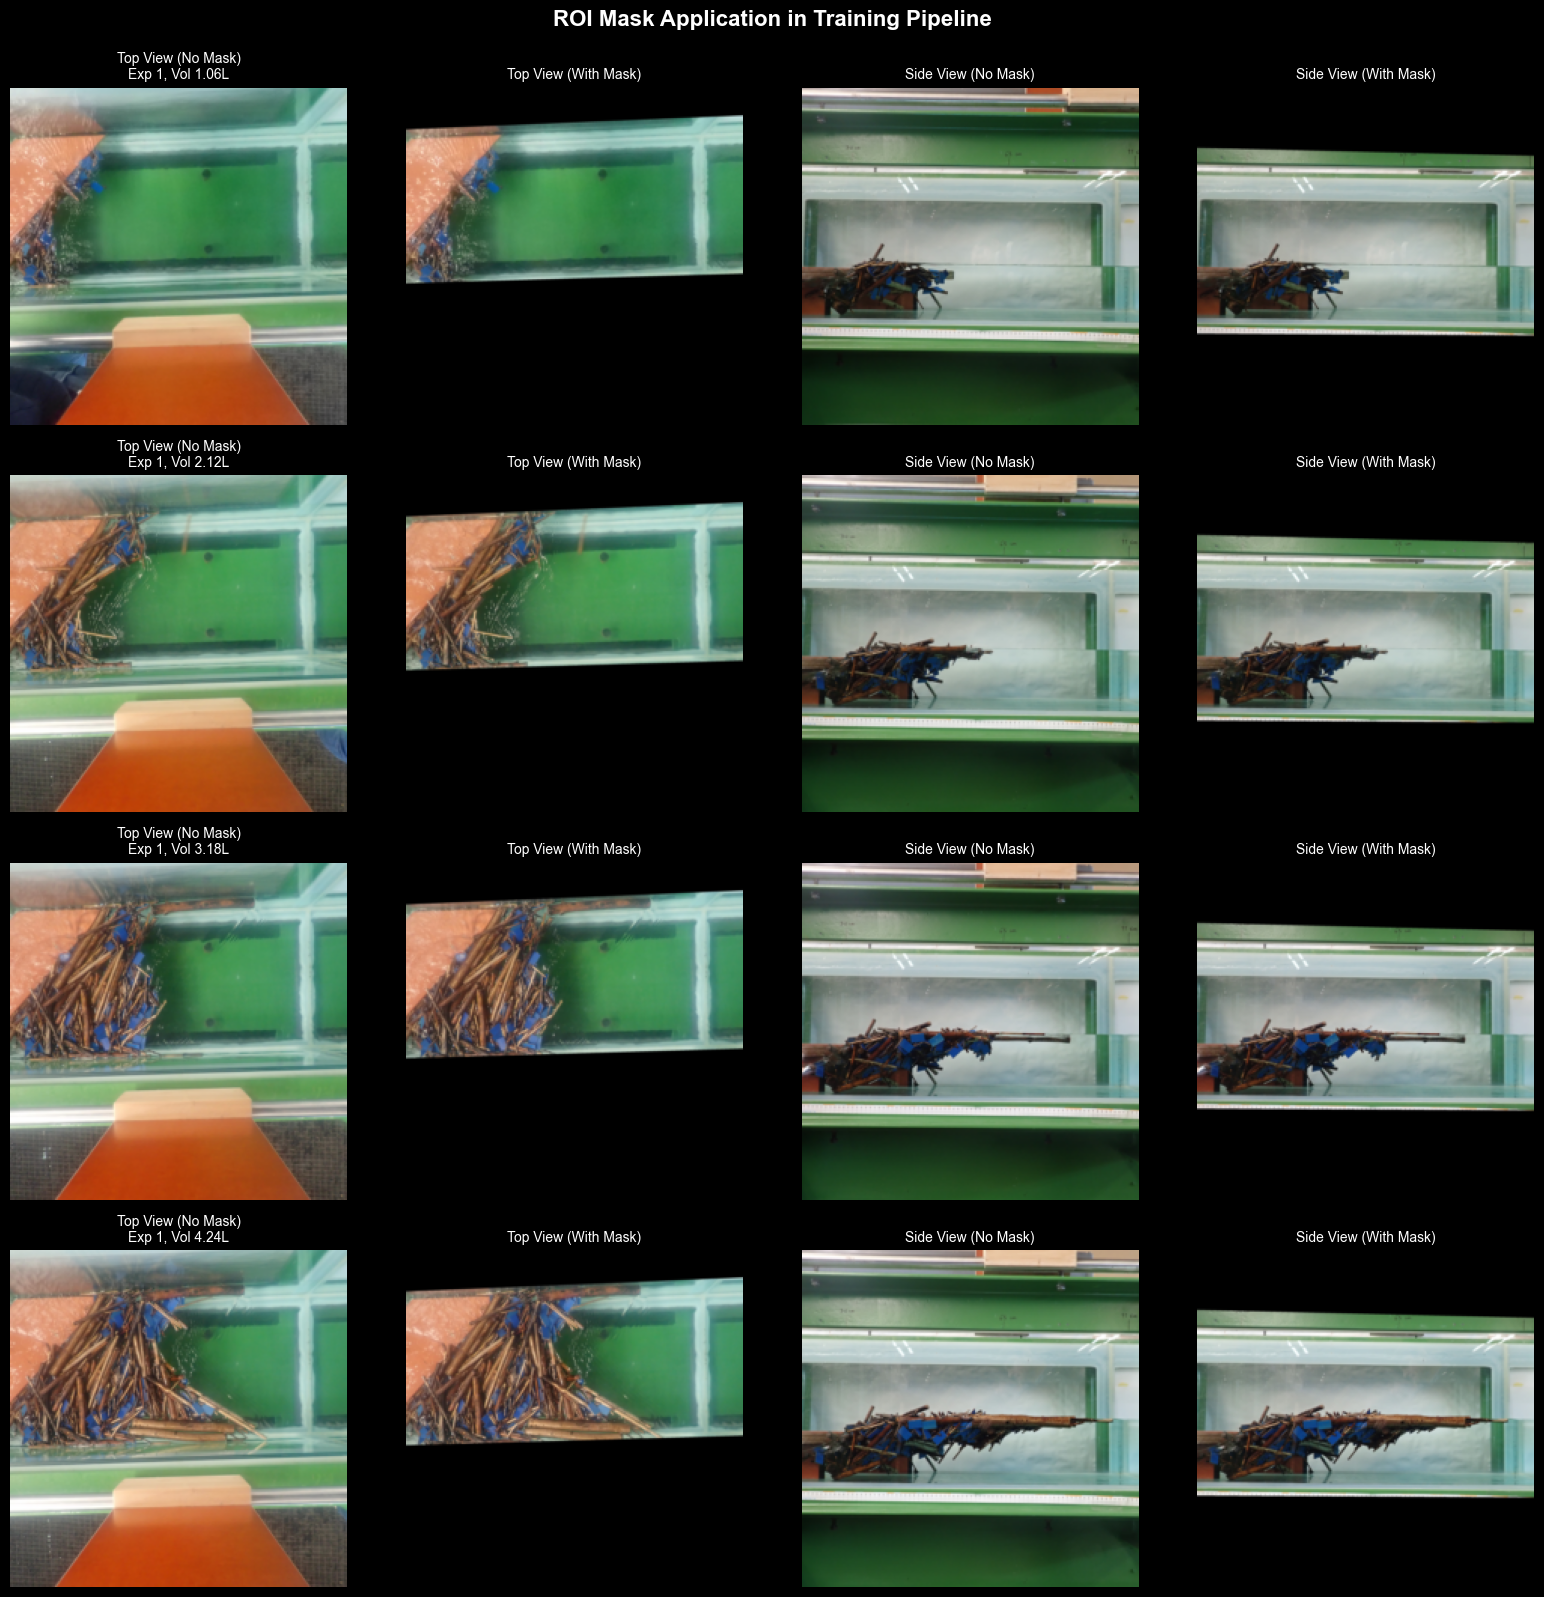

In [5]:
# Create visualization
fig, axes = plt.subplots(batch_size, 4, figsize=(16, 4 * batch_size))
fig.suptitle('ROI Mask Application in Training Pipeline', fontsize=16, fontweight='bold', y=0.995)

for i in range(batch_size):
    # Top view without mask
    axes[i, 0].imshow(top_no_mask[i])
    axes[i, 0].set_title(f'Top View (No Mask)\nExp {batch_df.iloc[i]["exp_id"]}, Vol {batch_df.iloc[i]["volume"]}L', fontsize=10)
    axes[i, 0].axis('off')
    
    # Top view with mask
    axes[i, 1].imshow(top_with_mask[i])
    axes[i, 1].set_title(f'Top View (With Mask)', fontsize=10)
    axes[i, 1].axis('off')
    
    # Side view without mask
    axes[i, 2].imshow(side_no_mask[i])
    axes[i, 2].set_title(f'Side View (No Mask)', fontsize=10)
    axes[i, 2].axis('off')
    
    # Side view with mask
    axes[i, 3].imshow(side_with_mask[i])
    axes[i, 3].set_title(f'Side View (With Mask)', fontsize=10)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('masked_batch_visualization.png', dpi=150, bbox_inches='tight')
print(f"Visualization saved to: masked_batch_visualization.png")
plt.show()

## Mask Statistics

In [6]:
# Show statistics about masked regions
print("Mask Statistics:")
print("=" * 60)

for i in range(batch_size):
    # Calculate percentage of masked pixels (black pixels after masking)
    top_masked_pixels = np.sum(np.all(top_with_mask[i] == 0, axis=-1))
    top_total_pixels = top_with_mask[i].shape[0] * top_with_mask[i].shape[1]
    top_mask_pct = (top_masked_pixels / top_total_pixels) * 100
    
    side_masked_pixels = np.sum(np.all(side_with_mask[i] == 0, axis=-1))
    side_total_pixels = side_with_mask[i].shape[0] * side_with_mask[i].shape[1]
    side_mask_pct = (side_masked_pixels / side_total_pixels) * 100
    
    top_path = batch_df.iloc[i]['top_path']
    top_filename = Path(top_path).name
    mask_used = "TOP_ROI_MASK_1" if top_filename <= "P2050047.JPG" else "TOP_ROI_MASK_2"
    
    print(f"Sample {i+1} (Exp {batch_df.iloc[i]['exp_id']}, Vol {batch_df.iloc[i]['volume']}L):")
    print(f"  Top image: {top_filename} ﷿﷿﷿﷿﷿﷿﷿﷿﷿ using {mask_used}")
    print(f"  Top view:  {top_mask_pct:.1f}% of pixels masked")
    print(f"  Side view: {side_mask_pct:.1f}% of pixels masked")
    print()

Mask Statistics:
Sample 1 (Exp 1, Vol 1.06L):
  Top image: P2260331.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ using TOP_ROI_MASK_2
  Top view:  0.0% of pixels masked
  Side view: 0.0% of pixels masked

Sample 2 (Exp 1, Vol 2.12L):
  Top image: P2260332.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ using TOP_ROI_MASK_2
  Top view:  0.0% of pixels masked
  Side view: 0.0% of pixels masked

Sample 3 (Exp 1, Vol 3.18L):
  Top image: P2260333.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ using TOP_ROI_MASK_2
  Top view:  0.0% of pixels masked
  Side view: 0.0% of pixels masked

Sample 4 (Exp 1, Vol 4.24L):
  Top image: P2260334.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ using TOP_ROI_MASK_2
  Top view:  0.0% of pixels masked
  Side view: 0.0% of pixels masked



## Check Which Top Mask is Used for Different Images

In [7]:
print("\nExamples from the dataset:")
sample_indices = [0, 50, 100, 139]
for idx in sample_indices:
    if idx < len(samples):
        top_path = samples.iloc[idx]['top_path']
        top_filename = Path(top_path).name
        mask_used = "TOP_ROI_MASK_1" if top_filename <= "P2050047.JPG" else "TOP_ROI_MASK_2"
        print(f"  Sample {idx}: {top_filename} ﷿﷿﷿﷿﷿﷿﷿﷿﷿ {mask_used}")


Examples from the dataset:
  Sample 0: P2260331.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ TOP_ROI_MASK_2
  Sample 50: P2270385.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ TOP_ROI_MASK_2
  Sample 100: P3020435.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ TOP_ROI_MASK_2
  Sample 139: P3050477.JPG ﷿﷿﷿﷿﷿﷿﷿﷿﷿ TOP_ROI_MASK_2
